The goal here is to do a *single* forward model that could be compared to a single MSA exposure.  This notebook identifies a good candidate for this from the calibration targets

In [1]:
from pathlib import Path
from matplotlib import pyplot as plt

import numpy as np

from astropy import visualization as viz
from jwst import datamodels

from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy import table

import requests

In [2]:
n6791fits = list(Path('../ngc6791_cals').glob('*.fits'))
ic166fits = list(Path('../ic166_cals/').glob('*.fits'))
m71fits = list(Path('../m71_cals/').glob('*.fits'))

dm0 = datamodels.open(n6791fits[0])
dm0.info()

root (AsdfObject)
├─asdf_library (Software)
│ ├─author (str): The ASDF Developers
│ ├─homepage (str): http://github.com/asdf-format/asdf
│ ├─name (str): asdf
│ └─version (str): 5.0.0
├─history (dict)
│ └─extensions (list) ...
├─_fits_hash (str): 0eb414a289c275d021142f61dde4a617b19d389e28f6ae3c1799b9cd500086a8
├─cal_logs (dict)
│ ├─calwebb_detector1 (list) ...
│ └─calwebb_spec2 (list) ...
├─meta (dict)
│ ├─aperture (dict) ...
│ ├─asn (dict) ...
│ ├─cal_step (dict) ...
│ ├─calibration_software_revision (str): RELEASE
│ ├─calibration_software_version (str): 1.20.2
│ ├─compress (bool): False
│ ├─data_processing_software_version (str): 2025_4a
│ ├─date (str): 2025-12-23T01:58:56.828
│ └─26 not shown
└─slits (list) ...
Some nodes not shown.


In [3]:
{k:v for k,v in dm0.slits[0].items() if 'meta' not in k}

{'barshadow': array([[1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1.]], dtype='>f4'),
 'barshadow_corrected': False,
 'cal_logs.assign_wcs': ['2025-12-23T01:55:43.285 - stpipe.step - INFO - Step assign_wcs running with args (<ImageModel(2048, 2048) from jw02609010001_03101_00001_nrs1_rate.fits>,).', '

In [4]:
source_coos = SkyCoord([s.source_ra for s in dm0.slits], [s.source_dec for s in dm0.slits], unit=u.deg)

In [5]:
maxarcmin = max(np.ptp(source_coos.ra.arcmin), np.ptp(source_coos.dec.arcmin))
source_coos.ra.deg.mean()

np.float64(290.21754211471136)

In [6]:
maxarcmin = max(np.ptp(source_coos.ra.arcmin), np.ptp(source_coos.dec.arcmin))

params = 'typical'
params = 'apogee_id,ra,dec,snr,vhelio_avg,verr,vscatter,teff,logg,m_h,alpha_m,gaiaedr3_phot_g_mean_mag'

apogeeres = requests.get('https://skyserver.sdss.org/DR19/SkyserverWS/IRSpectraQuery/ConeIR', {'ra': source_coos.ra.deg.mean(), 
                                                                                            'dec': source_coos.dec.deg.mean(), 
                                                                                            'radius': maxarcmin, 
                                                                                        'format': 'csv', 'irspecparams': params,
                                                                                        'limit': 500})

assert apogeeres.ok, apogeeres

aptab = table.Table.read(apogeeres.text, format='ascii')
assert len(aptab) < 500, 'hit limit'
aptab['coord'] = SkyCoord.guess_from_table(aptab, unit=u.deg)
aptab

apogee_id,ra,dec,snr,vhelio_avg,verr,vscatter,teff,logg,m_h,alpha_m,gaiaedr3_phot_g_mean_mag,coord
,,,,,,,,,,,,"deg,deg"
str18,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,SkyCoord
2M19210145+3748051,290.256045,37.801441,130.7759,-47.49223,0.03929335,0.08650374,4594.504,2.847268,0.34626,0.045564,15.3701,"290.256045,37.801441"
2M19210145+3748051,290.256045,37.801441,130.7759,-47.49223,0.03929335,0.08650374,4594.504,2.847268,0.34626,0.045564,15.3701,"290.256045,37.801441"
2M19210145+3748051,290.256045,37.801441,130.7759,-47.49223,0.03929335,0.08650374,4594.504,2.847268,0.34626,0.045564,15.3701,"290.256045,37.801441"
2M19210145+3748051,290.256045,37.801441,130.7759,-47.49223,0.03929335,0.08650374,4594.504,2.847268,0.34626,0.045564,15.3701,"290.256045,37.801441"
2M19210145+3748051,290.256045,37.801441,130.7759,-47.49223,0.03929335,0.08650374,4594.504,2.847268,0.34626,0.045564,15.3701,"290.256045,37.801441"
2M19205958+3748108,290.248262,37.803005,37.02339,-46.7002,0.04866308,0.04589014,4454.226,2.641004,0.37823,-0.032059,15.0756,"290.248262,37.803005"
2M19205958+3748108,290.248262,37.803005,37.02339,-46.7002,0.04866308,0.04589014,4454.226,2.641004,0.37823,-0.032059,15.0756,"290.248262,37.803005"
2M19205958+3748108,290.248262,37.803005,37.02339,-46.7002,0.04866308,0.04589014,4454.226,2.641004,0.37823,-0.032059,15.0756,"290.248262,37.803005"


(-1.0, 1.0)

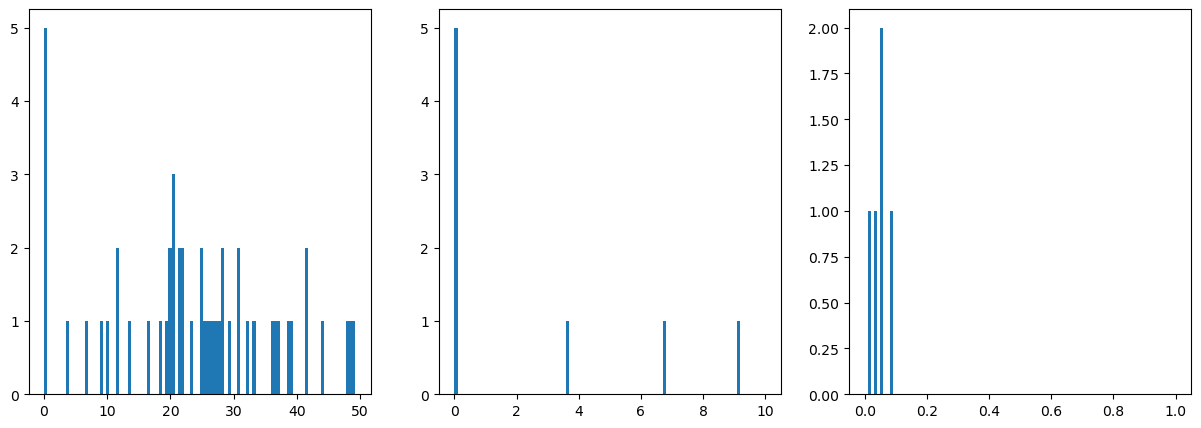

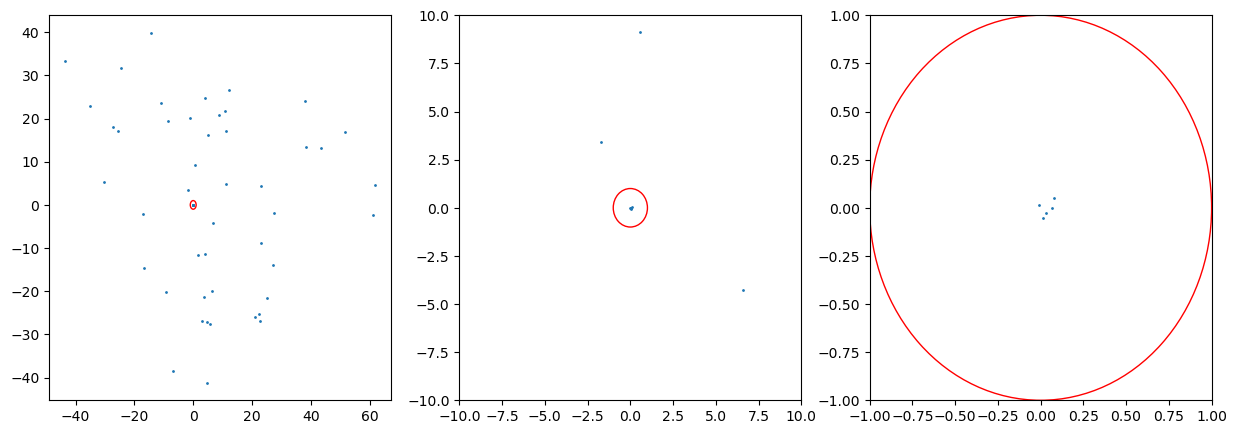

In [7]:
idx, d2d, _ = source_coos.match_to_catalog_sky(aptab['coord'])

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
ax1.hist(d2d.arcsec, bins=100)
ax2.hist(d2d.arcsec, bins=100, range=[0, 10])
ax3.hist(d2d.arcsec, bins=100, range=[0, 1])

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
dra = (source_coos.ra - aptab['coord'][idx].ra).arcsec
ddec = (source_coos.dec - aptab['coord'][idx].dec).arcsec
for ax in axs:
    ax.scatter(dra, ddec,s=1)
    ax.add_patch(plt.Circle((0, 0), 1, fill=False, color='r'))

axs[1].set_xlim(-10, 10)
axs[1].set_ylim(-10, 10)
axs[2].set_xlim(-1, 1)
axs[2].set_ylim(-1, 1)

In [15]:
msk = d2d.arcsec < 1
ap_matches = aptab[idx][msk]
slit_matches = [s for s,m in zip(dm0.slits, msk) if m]

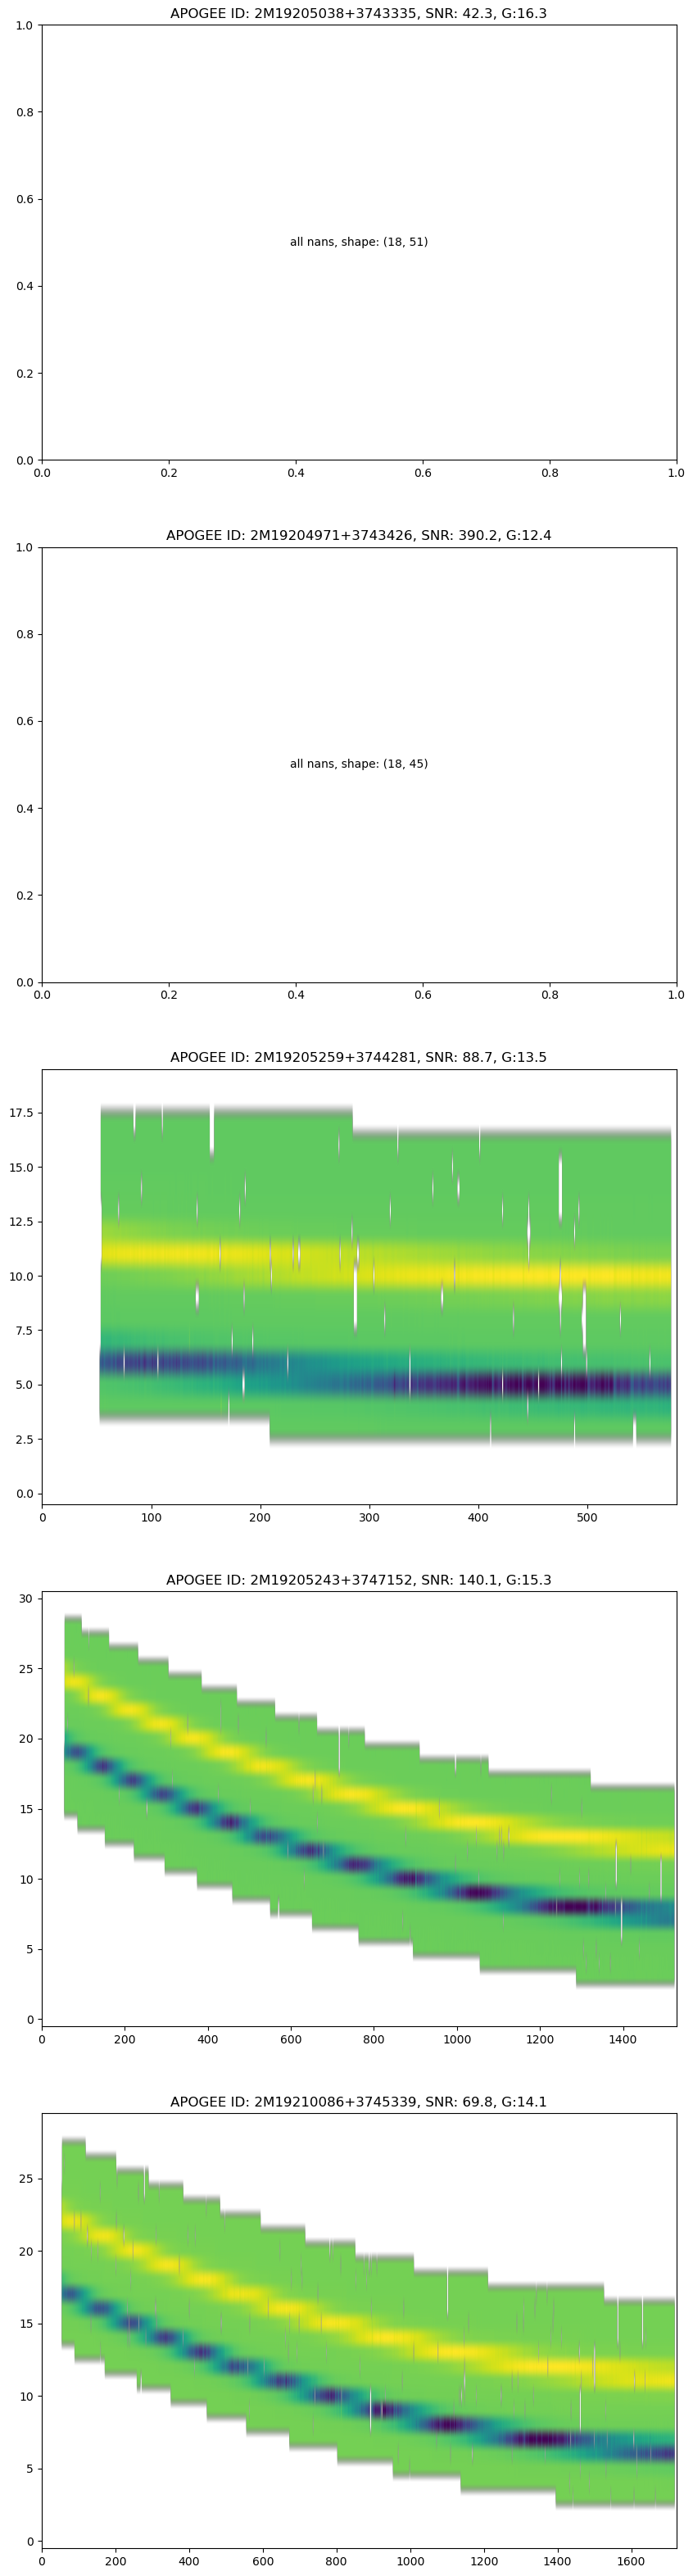

In [9]:
fig, axs = plt.subplots(len(ap_matches), 1, figsize=(10, 8*len(ap_matches)))

for slit, ap, ax in zip(slit_matches, ap_matches, axs.ravel()):
    if np.isfinite(slit.data).any():
        viz.imshow_norm(slit.data, ax=ax, origin='lower', aspect='auto', interval=viz.PercentileInterval(99.5), stretch=viz.AsinhStretch())
    else:
        ax.text(0.5, 0.5, f'all nans, shape: {slit.data.shape}', ha='center', va='center')
    ax.set_title(f"APOGEE ID: {ap['apogee_id']}, SNR: {ap['snr']:.1f}, G:{ap['gaiaedr3_phot_g_mean_mag']:.1f}")

The last of these looks like the best result:

In [31]:
print(slit_matches[-1].source_name)
print('slit index', np.where(msk)[0][-1])
assert slit_matches[-1].source_name == dm0.slits[np.where(msk)[0][-1]].source_name

ap_matches[-1]

2609_21
slit index 49


apogee_id,ra,dec,snr,vhelio_avg,verr,vscatter,teff,logg,m_h,alpha_m,gaiaedr3_phot_g_mean_mag,coord
,,,,,,,,,,,,"deg,deg"
str18,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,SkyCoord
2M19210086+3745339,290.253593,37.759418,69.77232,-45.42058,0.02989704,0.1100559,4416.742,2.269546,0.34755,0.0313609,14.1097,"290.253593,37.759418"
